# How to optimize the initial layout

Here, we show how to optimize the initial mapping using the `SATMapper` class. This class implements the initial mapping framework developped by A. Matsuo *et al.* published in [IEICE Trans. Fundam. Electron. Commun. Comput. Sci. (2023) 2022EAP1159](https://doi.org/10.1587/transfun.2022EAP1159). The idea is to find a placement of the decision variables to qubits that minimizes the number of SWAP layers that are needed.
Figure (a) below shows a network of $R_{ZZ}$ gates that can be interpreted as a graph in (b). We refer to the graph in (b) as the *problem graph*. Figure (c) shows a line coupling map as the black edges in a graph $C(0)$. The red edges correspond to the additional qubit connections that the first layer of SWAP gates, shown in red in (d), implement. This defines a new graph $C(1)$. The blue edges in (c) are the additional qubit connections that the second layer of SWAP gates, shown in blue in (d), implement. This defines a new graph $C(2)$.

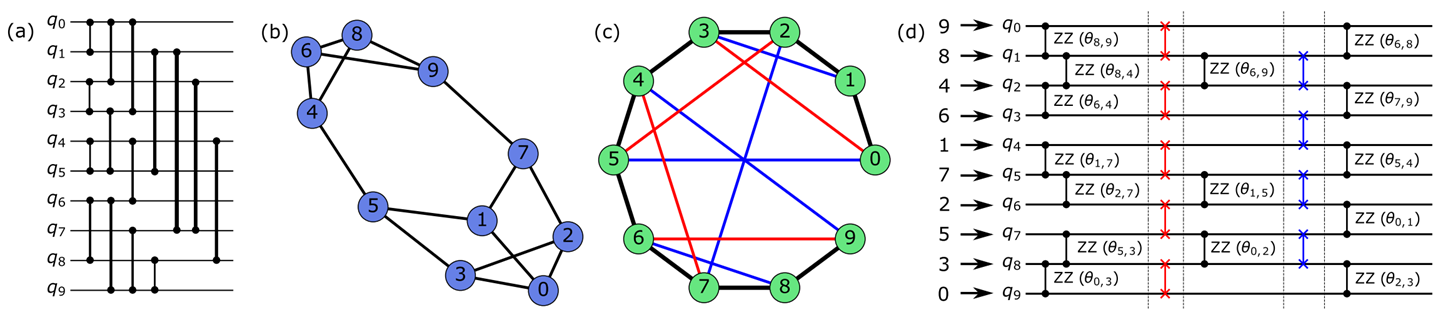

Therefore, for a given number of SWAP layers $\ell\in\mathbb{N}$ we seek a permutation of the nodes of the problem graph, such that it can be embeded by the coupling map $C(\ell)$ produced by the $\ell$ swap layers. This problem can be formulate as a boolean SAT problem and the permutation is the initial mapping we are looking for. Crucially, such permutations may not exist if $\ell$ is too small. By contrast, if $\ell$ is large enough$-$for example, $\ell=n-2$ for a line swap strategy$-$then the problem is trivial to solve since the coupling map may be fully connected.

The `SATMapper` in this repository attempts to find the smallest possible $\ell$ such that there exists a valid initial mapping. The SAT mapper does this via a binary search over $\ell$ and solves a SAT problem for each value of $\ell$. Importantly, there are values of $\ell$ for which the underlying SAT problems are very hard to solve. Therefore, the `SATmapper` has a built in timeout and will assume that it cannot find a valid initial mapping for a given $\ell$ if the timeout is exceeded. We now show the impact that the `SATMapper` can have on the circuit depth.


### 1. Problem setup

We first start with a random regular graph.

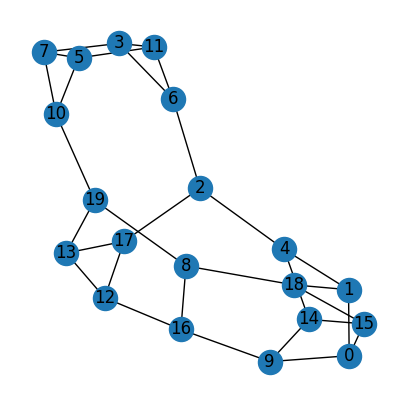

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

graph = nx.random_regular_graph(n=20, d=3, seed=0)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
nx.draw(graph, with_labels=True, ax=ax)

This graph has 20 nodes and 30 edges, and it can be encoded in 20 qubits. We convert it to a cost-operator format and build a QAOA circuit with and without the SAT mapping.

In [2]:
from qiskit.quantum_info import SparsePauliOp
from qopt_best_practices.utils import build_max_cut_paulis

cost_op = SparsePauliOp.from_list(build_max_cut_paulis(graph))

We will construct the circuit for a line of qubits with and without the initial mapping. For this, we setup a backend built from a line coupling map to which we will transpile to.

In [3]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap
from qiskit import transpile

cmap = CouplingMap([(idx, idx + 1) for idx in range(graph.order()-1)])
backend = GenericBackendV2(
    num_qubits=20, coupling_map=cmap, basis_gates=["x", "sx", "rzz", "id", "rz"], seed=0
)

### 2. Transpilation without the `SATMapper`

We setup a line swap strategy.

In [4]:
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy

swap_strategy = SwapStrategy.from_line([i for i in range(graph.order())])

For the transpilation, we will use the pre-init section of the prset QAOA pass manager wihtout the gate synthesis and simplification. This allows us to stop the transpilation at the level of the SWAP routing so that we can clearly see the impact of the SAT mapping on the circuit depth.

In [5]:
from qiskit.transpiler import PassManager
from qopt_best_practices.transpilation.annotated_transpilation_passes import (
    AnnotatedPrepareCostLayer,
    AnnotatedCommuting2qGateRouter,
    AnnotatedSwapToFinalMapping,
    UnrollBoxes,
)

pre_init = PassManager([AnnotatedPrepareCostLayer(), AnnotatedCommuting2qGateRouter(swap_strategy), AnnotatedSwapToFinalMapping(), UnrollBoxes()])

As can be seen below, the circuit is very deep.

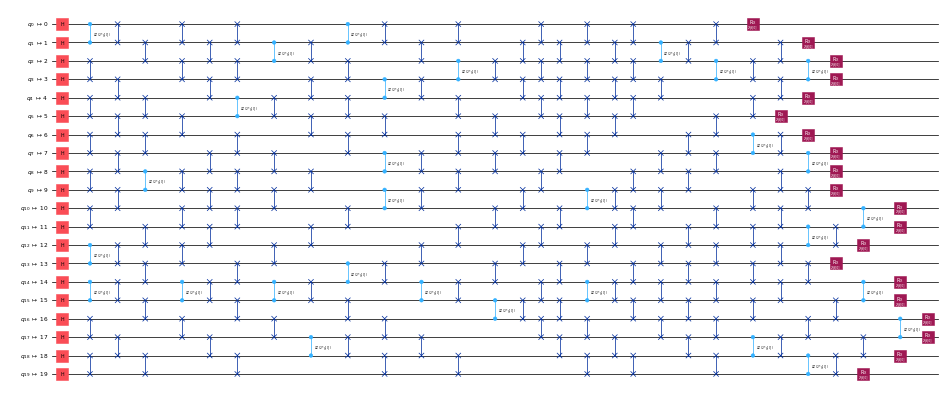

In [6]:
from qopt_best_practices.circuit_library import annotated_qaoa_ansatz

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ansatz = pre_init.run(annotated_qaoa_ansatz(cost_op, reps=1))
ansatz.draw("mpl", fold=False, ax=ax)

### 2. Find an intial mapping with the `SATMapper`

We now show how to find the initial mapping with the SATMapper. This requires the graph or cost operator to remap as well as the SWAP strategy.

In [7]:
from qopt_best_practices.qubit_mapping import SATMapper

sm = SATMapper(timeout=10)
sat_cost_op, sat_map, min_sat_layers = sm.remap_graph_with_sat(graph=cost_op, swap_strategy=swap_strategy)

print("Map from old to new edges: ", sat_map)
print("Min SAT layers:", min_sat_layers)

Map from old to new edges:  {0: 6, 1: 11, 2: 13, 3: 3, 4: 12, 5: 0, 6: 2, 7: 1, 8: 9, 9: 17, 10: 7, 11: 5, 12: 18, 13: 19, 14: 16, 15: 15, 16: 10, 17: 14, 18: 4, 19: 8}
Min SAT layers: InitialMappingResult(mapping={0: 6, 1: 11, 2: 13, 3: 3, 4: 12, 5: 0, 6: 2, 7: 1, 8: 9, 9: 17, 10: 7, 11: 5, 12: 18, 13: 19, 14: 16, 15: 15, 16: 10, 17: 14, 18: 4, 19: 8}, objective_value=5, objective_name='num_swap_layers', elapsed_time=0.18887399999999932, metadata={'num_swap_layers': 5, 'sat_result': SATResult(satisfiable=True, solution=[-1, -2, -3, -4, -5, -6, 7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31, 32, -33, -34, -35, -36, -37, -38, -39, -40, -41, -42, -43, -44, -45, -46, -47, -48, -49, -50, -51, -52, -53, 54, -55, -56, -57, -58, -59, -60, -61, -62, -63, 64, -65, -66, -67, -68, -69, -70, -71, -72, -73, -74, -75, -76, -77, -78, -79, -80, -81, -82, -83, -84, -85, -86, -87, -88, -89, -90, -91, -92, 93, -94, -95, -96, -97, -9

The resulting QAOA circuit with the SAT-remapped cost operator is significantly shallower than the original one.

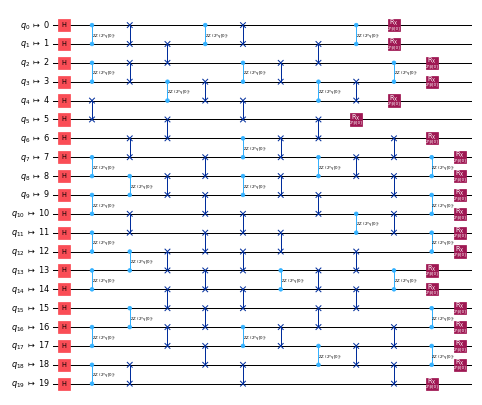

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sat_ansatz = pre_init.run(annotated_qaoa_ansatz(sat_cost_op, reps=1))
sat_ansatz_t = transpile(sat_ansatz, coupling_map=[[i,i+1] for i in range(sat_ansatz.num_qubits-1)], optimization_level=1)
sat_ansatz_t.draw("mpl", fold=False, ax=ax)

### 3. Find an initial mapping with the `SimulatedAnnealingMapper`

The performance of QAOA circuits with non-all-to-all two-qubit interactions can often be improved substantially by optimizing the initial qubit order before applying a SWAP-based encoding. This idea is explored in J. A. Montanez-Barrera *et al.*, [Optimizing QAOA circuit transpilation with parity twine and SWAP network encodings](https://arxiv.org/abs/2505.17944), where simulated annealing is used to search over qubit permutations and reduce the two-qubit overhead introduced by the encoding. The paper studies both parity-twine and SWAP-network encodings; here we use the same heuristic idea in the `SimulatedAnnealingMapper` for the `SwapStrategy` used in this repository.

The simulated annealing routine starts from an initial ordering and repeatedly proposes neighboring layouts by randomly swapping pairs of qubit labels. The objective is to favor layouts that avoid unnecessary two-qubit interactions introduced by the routing pattern at the end of the QAOA layer. For a given qubit permutation, the cost function evaluates how many two-qubit gates can be removed by checking, layer by layer from the outermost layers inward, whether the mapped qubit pairs correspond to native edges in the hardware coupling graph. The process continues until a layer containing a qubit pair from the problem graph is encountered.

As in standard simulated annealing, an improving move is always accepted, while a worse move may still be accepted with some probability to escape local minima. The temperature is then reduced multiplicatively by the cooling rate until the stopping temperature or the iteration budget is reached.

In [9]:
import qopt_best_practices

sa_mapper = qopt_best_practices.qubit_mapping.SimulatedAnnealingMapper(
    initial_temp=0.01,
    cooling_rate=0.9999,
    stop_temp=1e-9,
    max_iter=10000,
    max_restarts=10,
    verbose=False,
)

sa_cost_op, sa_map, sa_cost = sa_mapper.remap_graph_with_sa(graph=cost_op, swap_strategy=swap_strategy)

print("Map from old to new edges:", sa_map)
print("Annealer cost:", sa_cost)

Map from old to new edges: {2: 0, 11: 1, 1: 2, 3: 3, 8: 4, 10: 5, 15: 6, 7: 7, 9: 8, 5: 9, 13: 10, 19: 11, 12: 12, 6: 13, 14: 14, 17: 15, 16: 16, 4: 17, 18: 18, 0: 19}
Annealer cost: SAResult(mapping={2: 0, 11: 1, 1: 2, 3: 3, 8: 4, 10: 5, 15: 6, 7: 7, 9: 8, 5: 9, 13: 10, 19: 11, 12: 12, 6: 13, 14: 14, 17: 15, 16: 16, 4: 17, 18: 18, 0: 19}, objective_value=-101, objective_name='cost', elapsed_time=1.4879560470581055, metadata={'cost': -101, 'trace': {'cost': [-16, -17, -18, -26, -27, -33, -34, -35, -37, -43, -44, -45, -46, -52, -53, -54, -55, -56, -64, -65, -72, -73, -74, -75, -83, -84, -88, -89, -90, -91, -16, -17, -18, -26, -36, -37, -44, -46, -54, -55, -56, -63, -64, -65, -69, -70, -71, -72, -73, -74, -75, -16, -17, -18, -26, -27, -34, -36, -37, -44, -45, -46, -56, -60, -61, -63, -64, -65, -74, -75, -82, -83, -84, -90, -91, -92, -93, -94, -97, -98, -99, -100, -101, -16, -17, -18, -26, -27, -36, -37, -43, -44, -45, -46, -56, -63, -64, -65, -71, -72, -73, -74, -75, -82, -83, -84, -90, 

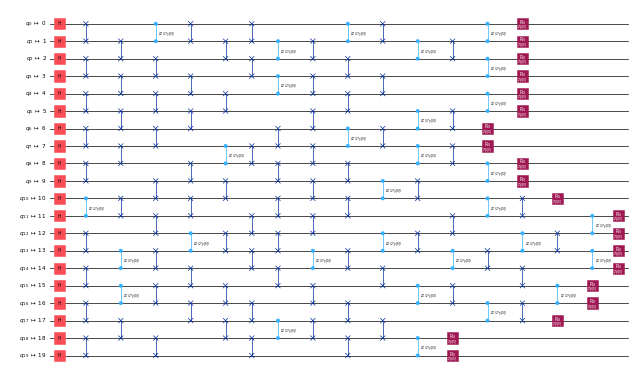

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sa_ansatz = pre_init.run(annotated_qaoa_ansatz(sa_cost_op, reps=1))
sa_ansatz_t = transpile(sa_ansatz, coupling_map=[[i,i+1] for i in range(sa_ansatz.num_qubits-1)], optimization_level=1)
sa_ansatz_t.draw("mpl", fold=False, ax=ax)

### 4. Summary

The circuit depth and gate count for the baseline, SAT-mapped, and simulated-annealing-mapped circuits are given below.

In [11]:
print("Two-qubit gate depth")
print("  without mapping:", ansatz.depth(lambda x: len(x.qubits) > 1))
print("  with SAT:       ", sat_ansatz_t.depth(lambda x: len(x.qubits) > 1))
print("  with SA:        ", sa_ansatz_t.depth(lambda x: len(x.qubits) > 1))

print("\nGate count")
print("  without mapping:", ansatz.count_ops())
print("  with SAT:       ", sat_ansatz_t.count_ops())
print("  with SA:        ", sa_ansatz_t.count_ops())

Two-qubit gate depth
  without mapping: 28
  with SAT:        10
  with SA:         16

Gate count
  without mapping: OrderedDict({'swap': 169, 'rzz': 30, 'h': 20, 'rx': 20})
  with SAT:        OrderedDict({'swap': 45, 'rzz': 30, 'h': 20, 'rx': 20})
  with SA:         OrderedDict({'swap': 80, 'rzz': 30, 'h': 20, 'rx': 20})


### 5. Scaling test

The next cell compares the SAT-based mapper and the simulated-annealing mapper on random 3-regular graphs as the problem size grows. The SAT budget is increased via `timeout`, and the simulated-annealing budget is increased via `max_iter`.

For each size, the cell records mapper runtime together with the resulting transpiled circuit metrics: two-qubit depth and total time.

In [12]:
import time

sa_mapper = qopt_best_practices.qubit_mapping.SimulatedAnnealingMapper(
    initial_temp=0.01,
    cooling_rate=0.9999,
    stop_temp=1e-9,
    max_iter=20_000,
    max_restarts=10,
    verbose=False,
)

sm = SATMapper(timeout=10)

nq_list = [10,20,30,40,50,60,70,80,90,100]
sa_depth, time_sa, sa_cx_count = [], [], []
sat_depth, time_sat, sat_cx_count = [], [], []    
for nq in nq_list:
    print(f"Mapping graph with {nq} nodes...")
    graph = nx.random_regular_graph(n=nq, d=3, seed=0)
    cost_op = SparsePauliOp.from_list(build_max_cut_paulis(graph))
    swap_strategy = SwapStrategy.from_line([i for i in range(graph.order())])
    pre_init = PassManager([AnnotatedPrepareCostLayer(), AnnotatedCommuting2qGateRouter(swap_strategy), AnnotatedSwapToFinalMapping(), UnrollBoxes()])
    # SAT mapping
    t_i_sat = time.time()
    sat_cost_op, sat_map, min_sat_layers = sm.remap_graph_with_sat(graph=cost_op, swap_strategy=swap_strategy)
    sat_ansatz = pre_init.run(annotated_qaoa_ansatz(sat_cost_op, reps=1))
    sat_ansatz_t = transpile(sat_ansatz, coupling_map=[[i,i+1] for i in range(sat_ansatz.num_qubits-1)], basis_gates=["u3", "cx"], optimization_level=1)
    t_f_sat = time.time() - t_i_sat
    time_sat.append(t_f_sat)
    sat_depth.append(sat_ansatz_t.depth(lambda x: len(x.qubits) > 1))
    sat_cx_count.append(sat_ansatz_t.count_ops().get("cx", 0))
    # SA mapping
    t_i_sa = time.time()
    sa_cost_op, sa_map, sa_cost = sa_mapper.remap_graph_with_sa(graph=cost_op, swap_strategy=swap_strategy)
    sa_ansatz = pre_init.run(annotated_qaoa_ansatz(sa_cost_op, reps=1))
    sa_ansatz_t = transpile(sa_ansatz, coupling_map=[[i,i+1] for i in range(sa_ansatz.num_qubits-1)], basis_gates=["u3", "cx"], optimization_level=1)
    t_f_sa = time.time() - t_i_sa
    sa_depth.append(sa_ansatz_t.depth(lambda x: len(x.qubits) > 1))
    sa_cx_count.append(sa_ansatz_t.count_ops().get("cx", 0))
    time_sa.append(t_f_sa)


Mapping graph with 10 nodes...
Mapping graph with 20 nodes...
Mapping graph with 30 nodes...
Mapping graph with 40 nodes...
Mapping graph with 50 nodes...
Mapping graph with 60 nodes...
Mapping graph with 70 nodes...
Mapping graph with 80 nodes...
Mapping graph with 90 nodes...
Mapping graph with 100 nodes...


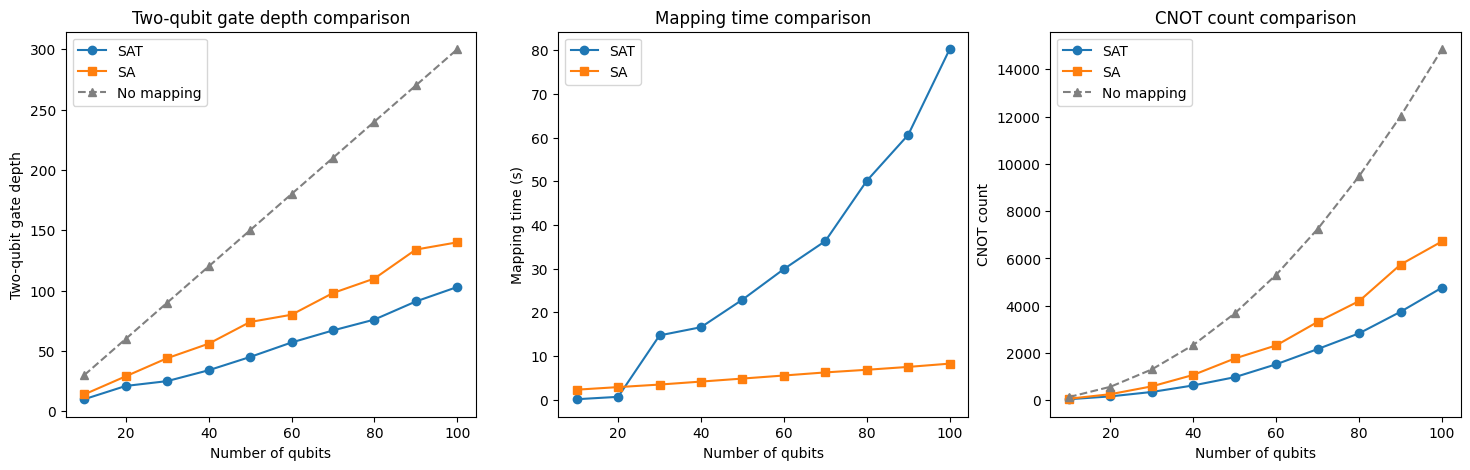

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(nq_list, sat_depth, label="SAT", marker="o")
ax[0].plot(nq_list, sa_depth, label="SA", marker="s")
ax[0].plot(nq_list, [3*nq for nq in nq_list], label="No mapping", marker="^", linestyle="--", color="gray")
ax[0].set_xlabel("Number of qubits")
ax[0].set_ylabel("Two-qubit gate depth")
ax[0].set_title("Two-qubit gate depth comparison")
ax[0].legend()
ax[1].plot(nq_list, time_sat, label="SAT", marker="o")
ax[1].plot(nq_list, time_sa, label="SA", marker="s")
ax[1].set_xlabel("Number of qubits")
ax[1].set_ylabel("Mapping time (s)")
ax[1].set_title("Mapping time comparison")
ax[1].legend()
ax[2].plot(nq_list, sat_cx_count, label="SAT", marker="o")
ax[2].plot(nq_list, sa_cx_count, label="SA", marker="s")
ax[2].plot(nq_list, [3*nq*(nq-1)//2 for nq in nq_list], label="No mapping", marker="^", linestyle="--", color="gray")
ax[2].set_xlabel("Number of qubits")
ax[2].set_ylabel("CNOT count")
ax[2].set_title("CNOT count comparison")
ax[2].legend()